# Regression Project: Auto MPG Prediction

โปรเจกต์นี้สร้างแบบจำลอง **Linear Regression** เพื่อทำนาย `mpg`
หรืออัตราการประหยัดเชื้อเพลิงของรถยนต์ หน่วยเป็น **miles per gallon (MPG)**

**Input features**
- `cylinders`
- `displacement`
- `horsepower`
- `weight`
- `acceleration`
- `model_year`
- `origin`

`name` จะไม่ถูกใช้เป็น feature เพราะเป็นชื่อ/ตัวระบุรถและมีค่าหลากหลายมาก

แหล่งข้อมูล: UCI Machine Learning Repository, Auto MPG  
https://archive.ics.uci.edu/dataset/9/auto+mpg  
License: CC BY 4.0


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# หาโฟลเดอร์โปรเจกต์ให้รันได้ทั้งจากในโฟลเดอร์ regression_auto_mpg
# หรือจากโฟลเดอร์แม่
if Path("data/mpg.csv").exists():
    PROJECT_DIR = Path(".")
elif Path("regression_auto_mpg/data/mpg.csv").exists():
    PROJECT_DIR = Path("regression_auto_mpg")
else:
    raise FileNotFoundError("ไม่พบ data/mpg.csv")

DATA_PATH = PROJECT_DIR / "data" / "mpg.csv"
MODEL_PATH = PROJECT_DIR / "model.joblib"

print("DATA_PATH =", DATA_PATH)


DATA_PATH = data/mpg.csv


## 1. อ่านและสำรวจข้อมูล

ตรวจจำนวนแถว/คอลัมน์ ชนิดข้อมูล และตัวอย่างข้อมูลก่อนเตรียมข้อมูล


In [2]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))


Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


,dtype
mpg,float64
cylinders,int64
displacement,float64
horsepower,object
weight,int64
acceleration,float64
model_year,int64
origin,int64
name,object


## 2. ตรวจ Missing Value

ในไฟล์นี้ `horsepower` ถูกอ่านเป็น `object` เพราะมีบางแถวใช้เครื่องหมาย `?`
แทนค่าที่หายไป จึงต้องแปลงเป็นตัวเลขก่อน โดยใช้ `errors="coerce"`
เพื่อเปลี่ยน `?` เป็น `NaN`


In [3]:
print("จำนวน '?' ใน horsepower ก่อนแปลง:",
      (df["horsepower"].astype(str).str.strip() == "?").sum())

df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

print("\nMissing values หลังแปลง:")
display(df.isna().sum().to_frame("missing"))


จำนวน '?' ใน horsepower ก่อนแปลง: 6

Missing values หลังแปลง:


,missing
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


**สำคัญ:** เราจะไม่คำนวณ median จากข้อมูลทั้งชุดแล้วเติมค่าก่อนแบ่งข้อมูล
เพราะจะทำให้ข้อมูลจาก test set รั่วเข้ามาในขั้นตอนเตรียมข้อมูล (data leakage)

เราจึงใส่ `SimpleImputer` ไว้ใน Pipeline ซึ่งจะเรียนรู้ median จาก **training set เท่านั้น**


## 3. Exploratory Data Analysis (EDA)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


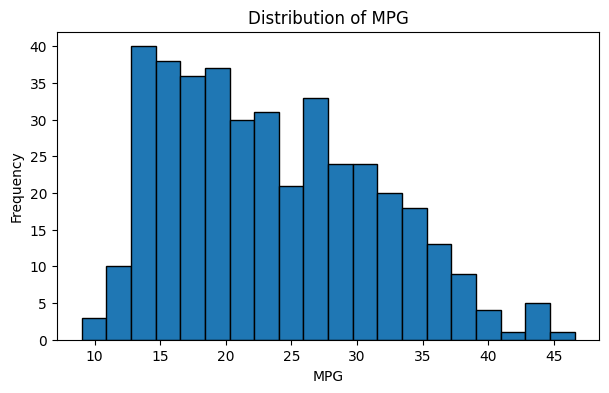

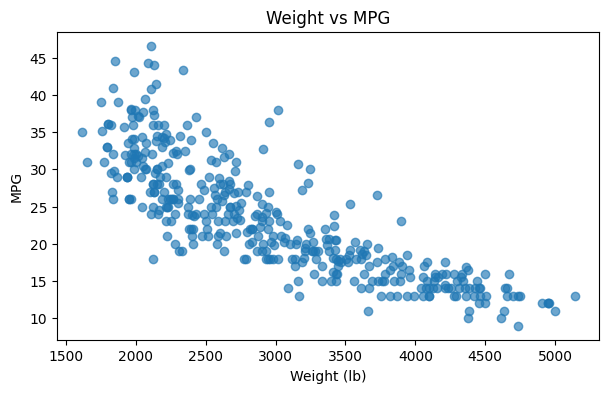

In [4]:
display(df.describe())

plt.figure(figsize=(7, 4))
plt.hist(df["mpg"], bins=20, edgecolor="black")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.title("Distribution of MPG")
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(df["weight"], df["mpg"], alpha=0.65)
plt.xlabel("Weight (lb)")
plt.ylabel("MPG")
plt.title("Weight vs MPG")
plt.show()


จาก scatter plot สามารถสังเกตแนวโน้มได้ว่าเมื่อรถมีน้ำหนักมากขึ้น ค่า MPG มักลดลง
ซึ่งเป็นความสัมพันธ์ที่มีเหตุผลสำหรับนำ `weight` มาเป็นหนึ่งในตัวแปรนำเข้า


## 4. กำหนด X และ y

In [5]:
features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
]
target = "mpg"

X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (398, 7)
y shape: (398,)


## 5. แบ่ง Training / Test Set

ใช้สัดส่วน 80/20 และกำหนด `random_state=42`
เพื่อให้สามารถแบ่งข้อมูลซ้ำได้เหมือนเดิม

Test set จะถูกเก็บไว้ใช้ **ประเมินผลครั้งสุดท้ายเท่านั้น**


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Training set: (318, 7) (318,)
Test set: (80, 7) (80,)


## 6. สร้าง Preprocessing Pipeline

- Numeric features: เติม missing ด้วย median แล้ว Standardize
- `origin`: มองเป็น categorical feature และใช้ One-Hot Encoding
- ทุกขั้นตอน fit จาก training set เท่านั้น


In [7]:
numeric_features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
]
categorical_features = ["origin"]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("regressor", LinearRegression()),
])

model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

## 7. ฝึกแบบจำลอง

เลือก **Linear Regression** เพราะ `mpg` เป็นค่าต่อเนื่อง
และ Linear Regression เป็นโมเดลพื้นฐานที่อธิบายได้ง่าย เหมาะสำหรับใช้เป็น regression baseline


In [8]:
model.fit(X_train, y_train)
print("Training completed")


Training completed


## 8. ประเมินผลบน Test Set

In [9]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.3f} MPG")
print(f"MSE  = {mse:.3f}")
print(f"RMSE = {rmse:.3f} MPG")
print(f"R^2  = {r2:.3f}")


MAE  = 2.288 MPG
MSE  = 8.339
RMSE = 2.888 MPG
R^2  = 0.845


### การแปลผล Metric

- **MAE**: ค่าเฉลี่ยของขนาดความผิดพลาด โดยไม่สนใจเครื่องหมาย หน่วยเป็น MPG
- **MSE**: ค่าเฉลี่ยของความผิดพลาดยกกำลังสอง จึงลงโทษความผิดพลาดขนาดใหญ่มากขึ้น
- **RMSE**: รากที่สองของ MSE จึงกลับมาอยู่ในหน่วย MPG และยังให้ความสำคัญกับ error ขนาดใหญ่
- **R²**: วัดสัดส่วนความแปรปรวนของ target ที่โมเดลอธิบายได้ โดย **ไม่ใช่เปอร์เซ็นต์ความแม่นยำ**

โปรเจกต์นี้ใช้ **RMSE เป็น metric หลัก** เพราะตีความได้ในหน่วย MPG
และเหมาะเมื่อต้องการให้ความผิดพลาดขนาดใหญ่มีน้ำหนักมากขึ้น


## 9. Actual vs Predicted

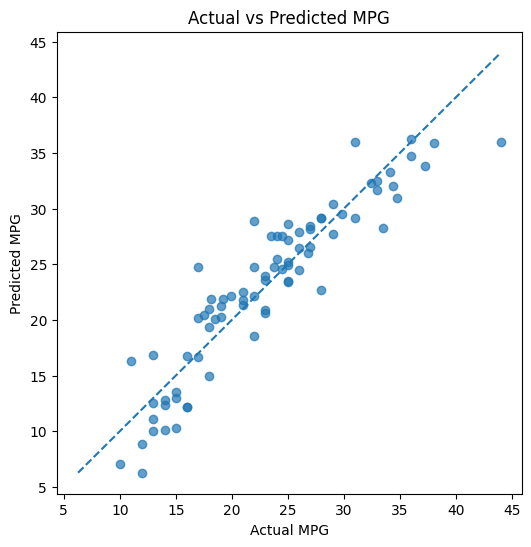

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())
plt.plot([low, high], [low, high], linestyle="--")

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")
plt.show()


## 10. ตัวอย่างผลทำนายและ Error Analysis

In [11]:
results = X_test.copy()
results["actual_mpg"] = y_test
results["predicted_mpg"] = y_pred
results["absolute_error"] = np.abs(
    results["actual_mpg"] - results["predicted_mpg"]
)

display(
    results.sort_values("absolute_error", ascending=False)
           .head(10)
           .round(2)
)


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,actual_mpg,predicted_mpg,absolute_error
394,4,97.0,52.0,2130,24.6,82,2,44.0,35.97,8.03
275,6,163.0,125.0,3140,13.6,78,2,17.0,24.72,7.72
389,6,232.0,112.0,2835,14.7,82,1,22.0,28.85,6.85
42,8,383.0,180.0,4955,11.5,71,1,12.0,6.28,5.72
124,8,350.0,180.0,3664,11.0,73,1,11.0,16.34,5.34
30,4,140.0,90.0,2264,15.5,71,1,28.0,22.68,5.32
238,4,98.0,83.0,2075,15.9,77,1,33.5,28.26,5.24
377,4,91.0,68.0,1970,17.6,82,3,31.0,36.00,5.00
5,8,429.0,198.0,4341,10.0,70,1,15.0,10.32,4.68
341,6,173.0,110.0,2725,12.6,81,1,23.5,27.52,4.02


ตารางด้านบนแสดงตัวอย่างที่โมเดลผิดพลาดมากที่สุดใน test set
ซึ่งช่วยให้เห็นข้อจำกัดของ Linear Regression ว่าความสัมพันธ์ระหว่างคุณลักษณะรถกับ MPG
อาจไม่ได้เป็นเส้นตรงทั้งหมด และยังมีปัจจัยอื่นที่ชุดข้อมูลนี้ไม่ได้เก็บไว้


## 11. ทดลองทำนายข้อมูลใหม่

In [12]:
example = pd.DataFrame([{
    "cylinders": 8,
    "displacement": 307.0,
    "horsepower": 130.0,
    "weight": 3504,
    "acceleration": 12.0,
    "model_year": 70,
    "origin": 1,
}])

example_pred = model.predict(example)[0]
print(f"Predicted MPG = {example_pred:.2f}")


Predicted MPG = 14.94


## 12. บันทึกแบบจำลอง

บันทึก **Pipeline ทั้งชุด** เพื่อให้เว็บแอปใช้ preprocessing
แบบเดียวกับตอนฝึกโดยอัตโนมัติ


In [13]:
joblib.dump(model, MODEL_PATH)
print("Saved model to:", MODEL_PATH)


Saved model to: model.joblib


## 13. สรุป

แบบจำลอง Linear Regression สามารถทำนาย MPG จากคุณลักษณะของรถยนต์ได้
โดยใช้ข้อมูล 80% สำหรับฝึกและ 20% สำหรับทดสอบ

ข้อจำกัดสำคัญคือชุดข้อมูลมีขนาดเล็กและเป็นข้อมูลรถรุ่นเก่า
ดังนั้นเว็บแอปนี้เหมาะสำหรับการสาธิตกระบวนการ Machine Learning
มากกว่าการใช้ประเมินรถยนต์สมัยใหม่จริง
